[Previous: Module 1: Complexity and Big-O](01_Complexity_and_Big_O.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 3: Hash Tables and Sets](03_Hash_Tables_and_Sets.ipynb)

# Module 2: Arrays, Linked Lists, Stacks and Queues

**Learning objectives.** After this module you can:

* explain why a Python list is fast at the end and slow at the front, and see the dynamic-array growth strategy in a plot;
* implement a linked list and say when it beats an array;
* use a stack and a queue, know which Python objects to reach for, and recognise them in recursion and scheduling;
* pick the right sequence container from a cost table.

**Prerequisites.** [Module 1](01_Complexity_and_Big_O.ipynb) for Big-O and `growth_plot`.

## 1. Arrays: one block of memory

A Python `list` is a **dynamic array**: one contiguous block of slots. Index $i$ is at a fixed offset from the start, so `a[i]` is O(1).
The price is paid at the front: inserting at index 0 must shift every element right, O(n).

When the block is full, Python allocates a bigger one (roughly 12 percent bigger, in steps) and copies. That copy is O(n), but it happens rarely,
so `append` is O(1) **amortised**. The plot below watches the allocated capacity jump while the length climbs smoothly.

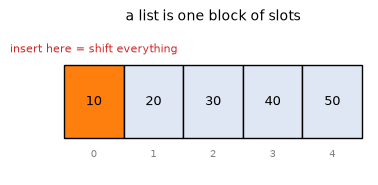

In [1]:
import sys, random, time
from collections import deque
import matplotlib.pyplot as plt
from dsalab import draw_array, draw_linked_list, time_it, growth_plot

draw_array([10, 20, 30, 40, 50], highlight={0: "tab:orange"}, labels={0: "insert here = shift everything"}, title="a list is one block of slots")

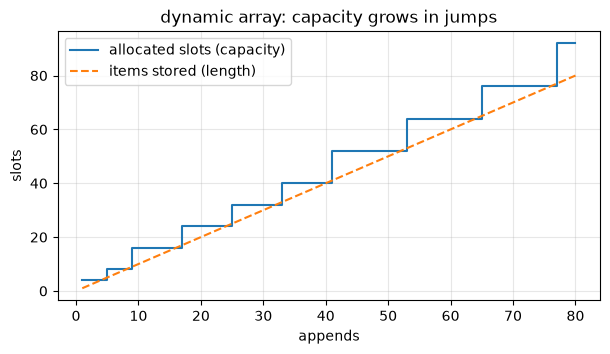

In [2]:
lengths, capacities = [], []
a = []
empty = sys.getsizeof([])
for i in range(80):
    a.append(i)
    lengths.append(len(a))
    capacities.append((sys.getsizeof(a) - empty) // 8)      # 8 bytes per slot on a 64-bit build

plt.figure(figsize=(7, 3.5))
plt.step(lengths, capacities, where="post", label="allocated slots (capacity)")
plt.plot(lengths, lengths, "--", label="items stored (length)")
plt.xlabel("appends"); plt.ylabel("slots"); plt.title("dynamic array: capacity grows in jumps"); plt.legend(); plt.grid(alpha=0.3); plt.show()

> **What to notice.** The capacity staircase stays above the length line and the steps get wider. Each step is one O(n) copy; between steps every append is O(1).

## 2. Linked lists: nodes and pointers

A **linked list** stores each item in its own node with a pointer to the next node. Nothing is contiguous, so there is no shifting:
inserting at the front is O(1). The price is the opposite of the array's: reaching item $i$ means walking $i$ pointers, O(n), and each node costs extra memory.

Below is a complete singly linked list in twenty lines, followed by a picture of it.

contents: [10, 20, 30, 40]  size: 4  find(20) -> 1
after delete(20): [10, 30, 40]


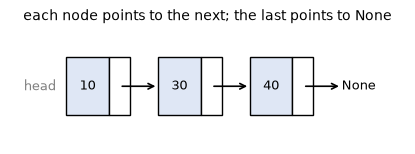

In [3]:
class Node:
    def __init__(self, value, next=None):
        self.value, self.next = value, next

class LinkedList:
    def __init__(self):
        self.head, self.size = None, 0

    def push_front(self, value):                 # O(1)
        self.head = Node(value, self.head)
        self.size += 1

    def append(self, value):                     # O(n): walk to the end (a tail pointer would make it O(1))
        node = Node(value)
        if self.head is None:
            self.head = node
        else:
            cur = self.head
            while cur.next:
                cur = cur.next
            cur.next = node
        self.size += 1

    def find(self, value):                       # O(n)
        cur, i = self.head, 0
        while cur:
            if cur.value == value:
                return i
            cur, i = cur.next, i + 1
        return -1

    def delete(self, value):                     # O(n) to find, O(1) to unlink
        prev, cur = None, self.head
        while cur:
            if cur.value == value:
                if prev:
                    prev.next = cur.next
                else:
                    self.head = cur.next
                self.size -= 1
                return True
            prev, cur = cur, cur.next
        return False

    def __iter__(self):
        cur = self.head
        while cur:
            yield cur.value
            cur = cur.next

ll = LinkedList()
for v in [30, 20, 10]:
    ll.push_front(v)
ll.append(40)
print("contents:", list(ll), " size:", ll.size, " find(20) ->", ll.find(20))
ll.delete(20)
print("after delete(20):", list(ll))
draw_linked_list(list(ll), title="each node points to the next; the last points to None")

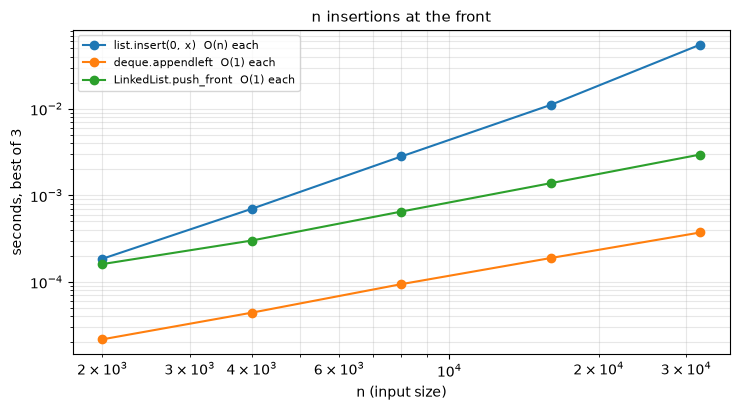

In [4]:
# The trade-off, measured: n insertions at the FRONT.
def list_insert_front(n):
    a = []
    for i in range(n):
        a.insert(0, i)

def deque_appendleft(n):
    d = deque()
    for i in range(n):
        d.appendleft(i)

def linked_push_front(n):
    ll = LinkedList()
    for i in range(n):
        ll.push_front(i)

sizes = [2000, 4000, 8000, 16000, 32000]
growth_plot({"list.insert(0, x)  O(n) each": list_insert_front,
             "deque.appendleft  O(1) each": deque_appendleft,
             "LinkedList.push_front  O(1) each": linked_push_front},
            sizes, title="n insertions at the front")

> **What to notice.** The list curve has slope 2 (n inserts times n shifts each). The other two have slope 1. The linked list is slower than the deque
> by a constant factor because every node is a Python object, which is why in practice you reach for `deque` and keep linked lists for interviews and for
> understanding trees and graphs, which are made of exactly these nodes and pointers.

## 3. Stacks: last in, first out

A **stack** supports `push` and `pop` at one end. The most recent item comes out first. A Python list is a perfect stack: `append` and `pop()` are both O(1).

Stacks show up whenever something must be undone in reverse order: matching brackets, the undo history in an editor, and the **call stack**
that every running program uses to remember where to return to. Below, bracket matching with a trace of the stack at each character.

In [5]:
def balanced(text, trace=False):
    pairs = {")": "(", "]": "[", "}": "{"}
    stack = []
    for ch in text:
        if ch in "([{":
            stack.append(ch)
        elif ch in ")]}":
            if not stack or stack.pop() != pairs[ch]:
                if trace: print(f"  {ch!r}: mismatch, stack was {stack}")
                return False
        if trace:
            print(f"  {ch!r}: stack = {''.join(stack)!r}")
    return not stack

for s in ["{[()]}", "([)]", "((", "print(f(x[0]))"]:
    print(f"{s!r}:")
    print("  ->", "balanced" if balanced(s, trace=True) else "NOT balanced")

'{[()]}':
  '{': stack = '{'
  '[': stack = '{['
  '(': stack = '{[('
  ')': stack = '{['
  ']': stack = '{'
  '}': stack = ''
  -> balanced
'([)]':
  '(': stack = '('
  '[': stack = '(['
  ')': mismatch, stack was ['(']
  -> NOT balanced
'((':
  '(': stack = '('
  '(': stack = '(('
  -> NOT balanced
'print(f(x[0]))':
  'p': stack = ''
  'r': stack = ''
  'i': stack = ''
  'n': stack = ''
  't': stack = ''
  '(': stack = '('
  'f': stack = '('
  '(': stack = '(('
  'x': stack = '(('
  '[': stack = '((['
  '0': stack = '((['
  ']': stack = '(('
  ')': stack = '('
  ')': stack = ''
  -> balanced


In [6]:
# The call stack, made visible: each nested call is a frame pushed on top of the previous one.
def factorial(n, depth=0):
    print("    " * depth + f"push factorial({n})")
    result = 1 if n <= 1 else n * factorial(n - 1, depth + 1)
    print("    " * depth + f"pop  factorial({n}) = {result}")
    return result

factorial(4)
print("\nPython's default recursion limit (max stack depth):", sys.getrecursionlimit())

push factorial(4)
    push factorial(3)
        push factorial(2)
            push factorial(1)
            pop  factorial(1) = 1
        pop  factorial(2) = 2
    pop  factorial(3) = 6
pop  factorial(4) = 24

Python's default recursion limit (max stack depth): 1000


## 4. Queues: first in, first out

A **queue** adds at the back and removes at the front, like a line at a counter. Removing from the front of a Python list is O(n) (the shift again),
so use `collections.deque`, which is O(1) at both ends.

Queues appear wherever fairness or arrival order matters: task scheduling, print jobs, and breadth-first search in Module 6.

In [7]:
# A round-robin scheduler: each task gets a 2-unit slice, then goes to the back of the line.
tasks = deque([("A", 5), ("B", 2), ("C", 4)])
clock = 0
while tasks:
    name, remaining = tasks.popleft()
    run = min(2, remaining)
    clock += run
    remaining -= run
    print(f"t={clock:>2}: ran {name} for {run}, {remaining} left" + ("" if remaining else "   done"))
    if remaining:
        tasks.append((name, remaining))

t= 2: ran A for 2, 3 left
t= 4: ran B for 2, 0 left   done
t= 6: ran C for 2, 2 left
t= 8: ran A for 2, 1 left
t=10: ran C for 2, 0 left   done
t=11: ran A for 1, 0 left   done


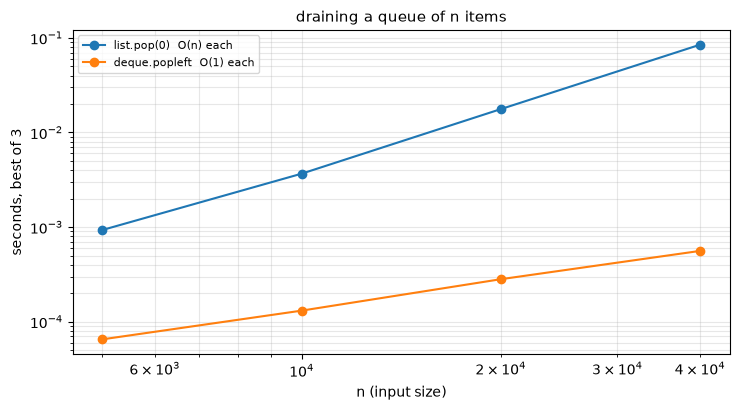

In [8]:
def list_pop_front(n):
    a = list(range(n))
    while a:
        a.pop(0)

def deque_pop_front(n):
    d = deque(range(n))
    while d:
        d.popleft()

growth_plot({"list.pop(0)  O(n) each": list_pop_front, "deque.popleft  O(1) each": deque_pop_front},
            [5000, 10000, 20000, 40000], title="draining a queue of n items")

## Cheat sheet: which sequence container?

| Need | Use | Why |
|------|-----|-----|
| index by position, append at the end | `list` | O(1) for both |
| add or remove at the front (or both ends) | `collections.deque` | O(1) at both ends |
| LIFO (undo, matching, recursion by hand) | `list` as a stack | `append` and `pop()` |
| FIFO (fair scheduling, BFS) | `deque` | `append` and `popleft` |
| insert or delete in the middle by pointer, no index needed | linked list | O(1) relink, no shifting |
| a sorted sequence with fast search | `list` + `bisect` (Module 4) | O(log n) search, O(n) insert |

## Try it yourself

**Exercise 1.** Add a `reverse()` method to `LinkedList` that reverses the pointers in place, O(n) time and O(1) extra space. Draw before and after.

**Exercise 2.** Implement a queue using two stacks (two lists). `enqueue` pushes on the first; `dequeue` pops from the second, refilling it from the first when empty. Argue why each element is moved at most once, so dequeue is O(1) amortised.

**Exercise 3.** A "min-stack" supports `push`, `pop` and `min` all in O(1). Hint: keep a second stack of running minimums.

**Exercise 4 (challenge).** Detect a cycle in a linked list without extra memory, using a slow pointer and a fast pointer.

<details><summary>Solutions</summary>

```python
# Exercise 1
def reverse(self):
    prev, cur = None, self.head
    while cur:
        cur.next, prev, cur = prev, cur, cur.next
    self.head = prev
LinkedList.reverse = reverse
ll = LinkedList(); [ll.append(v) for v in [1, 2, 3, 4]]
display(draw_linked_list(list(ll), title="before")); ll.reverse(); display(draw_linked_list(list(ll), title="after"))

# Exercise 2
class TwoStackQueue:
    def __init__(self): self.inbox, self.outbox = [], []
    def enqueue(self, x): self.inbox.append(x)
    def dequeue(self):
        if not self.outbox:
            while self.inbox: self.outbox.append(self.inbox.pop())
        return self.outbox.pop()
# Each element is pushed to inbox once, moved to outbox once, popped once: 3 operations per element, O(1) amortised.

# Exercise 3
class MinStack:
    def __init__(self): self.items, self.mins = [], []
    def push(self, x):
        self.items.append(x); self.mins.append(min(x, self.mins[-1]) if self.mins else x)
    def pop(self): self.mins.pop(); return self.items.pop()
    def min(self): return self.mins[-1]

# Exercise 4: Floyd's tortoise and hare
def has_cycle(head):
    slow = fast = head
    while fast and fast.next:
        slow, fast = slow.next, fast.next.next
        if slow is fast: return True
    return False
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [9]:
from dsalab import quiz

quiz(2)

Checkpoint quiz, Module 2 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. Inserting at the front of a Python list of n items costs
    a) O(1)
    b) O(log n)
    c) O(n)
    d) O(n^2)

Q2. The main advantage of a linked list over an array is
    a) faster access by index
    b) O(1) insertion or deletion at a known position, with no shifting
    c) less memory per element
    d) faster searching

Q3. Which structure processes items in the order they arrived?
    a) a stack
    b) a queue
    c) a hash table
    d) a heap

Q4. collections.deque gives
    a) O(1) append and pop at both ends
    b) O(1) access by index
    c) sorted order
    d) unique items only


## Key takeaways

* A list is a dynamic array: O(1) by index and at the end, O(n) at the front, capacity grows in jumps so append is amortised O(1).
* A linked list trades index access for O(1) relinking. Trees and graphs are built from the same nodes and pointers.
* Stack = LIFO (`list`), queue = FIFO (`deque`). Recursion runs on a stack; fair scheduling and BFS run on a queue.
* Choose by the operation you do most; the cheat sheet above is the decision table.

**Next:** the structure that makes lookup by key O(1). [Module 3](03_Hash_Tables_and_Sets.ipynb).

[Previous: Module 1: Complexity and Big-O](01_Complexity_and_Big_O.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 3: Hash Tables and Sets](03_Hash_Tables_and_Sets.ipynb)